In [3]:
import numpy as np
import xarray as xr
import pandas as pd
import datetime

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

import os
import math

#import dask
#from dask.distributed import Client
#from dask import delayed

import locale 

In [5]:
locale.setlocale(locale.LC_TIME, "es_ES");

# Inicio

In [13]:
# Daily data
ds = xr.open_dataset('../Data/grid2025/grid_1_sal.nc')


In [17]:
ds.close()

## Tendencia por coordenadas

c:\Users\ismae\miniconda3\envs\practicas\Lib\site-packages\xarray\core\dataarray.py:6386: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmax(dim, axis, keep_attrs, skipna)
c:\Users\ismae\miniconda3\envs\practicas\Lib\site-packages\xarray\core\dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


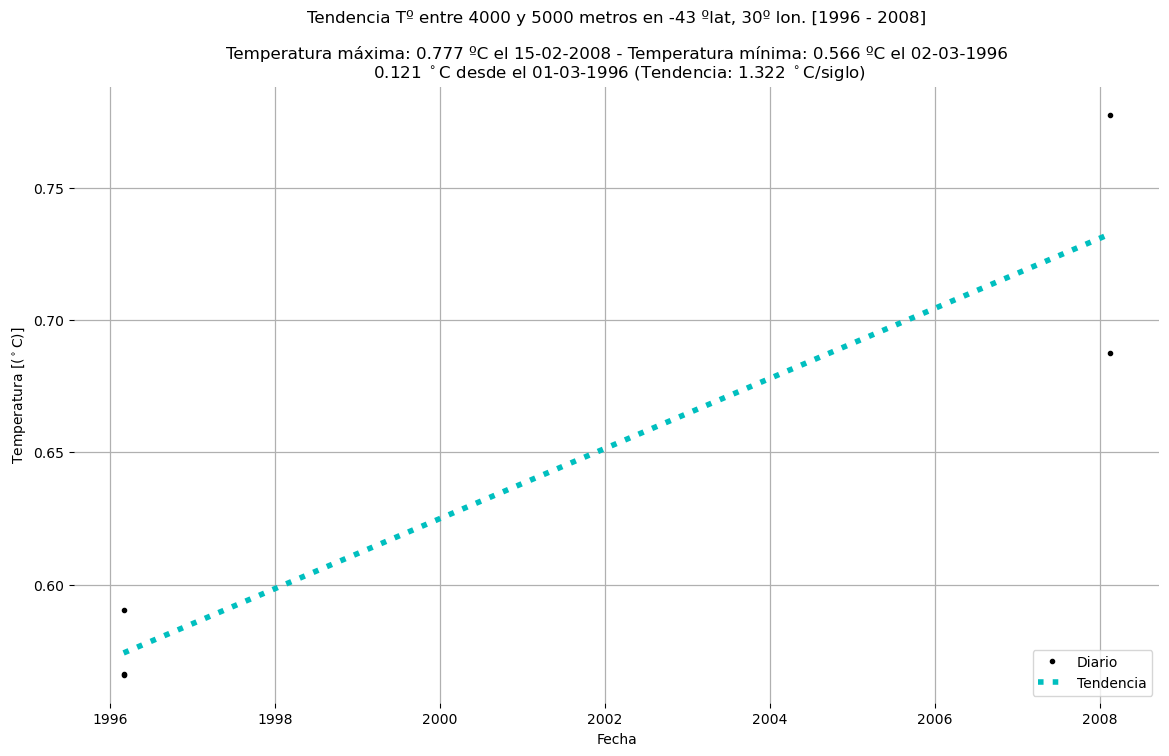

In [16]:
# Seleccionar un punto específico en latitude and longitude 
latitude = -43 # Define latitude
longitude = 30  # Define longitude

t_means_1d = ds.t_means.sel(latitude=latitude, longitude=longitude, method="nearest")
times_1d     = ds.times.sel(latitude=latitude, longitude=longitude, method="nearest") 
nans = np.where(np.isnan(times_1d) == True)
last_ind = np.min(nans) - 1

tmax = t_means_1d.isel(t_means_1d.argmax(...))
tmin = t_means_1d.isel(t_means_1d.argmin(...))

d_tmax = times_1d.isel(t_means_1d.argmax(...))
d_tmin = times_1d.isel(t_means_1d.argmin(...))

# Linear Fit
ind = np.isfinite(t_means_1d)
times_numeric = times_1d[ind].astype('datetime64[ns]').astype(np.int64)  # Convert times to numeric format
z = np.polyfit(times_numeric, t_means_1d[ind], 1)  # Perform linear fit
linearf = z[0] * times_1d.astype('datetime64[ns]').astype(np.int64) + z[-1]  # Calculate linear fit line
Dslope = z[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to °C per century


TituloFigura = f"Tendencia Tº entre 4000 y 5000 metros en {latitude} ºlat, {longitude}º lon."
tPeriodo = f" [{times_1d[0].dt.strftime('%Y').values} - {times_1d[last_ind].dt.strftime('%Y').values}]\n"
tTActual = f"{times_1d[last_ind].dt.strftime('%d-%m-%Y').values} %2.3f $^\\circ$C" % (t_means_1d[-1].values)
tTMaxima = f"Temperatura máxima: %2.3f ºC" % (t_means_1d.max().values) + f" el {times_1d[t_means_1d.argmax()].dt.strftime('%d-%m-%Y').values}"
tTMinima = f"Temperatura mínima: %2.3f ºC" % (t_means_1d.min().values) + f" el {times_1d[t_means_1d.argmin()].dt.strftime('%d-%m-%Y').values}"
tTendencia = (
    f"\n %2.3f $^\\circ$C" % (t_means_1d[last_ind] - t_means_1d[0])
    + f" desde el {times_1d[0].dt.strftime('%d-%m-%Y').values} "
    + f"(Tendencia: %2.3f" % (Dslope) + " $^\\circ$C/siglo)"
)

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.plot(times_1d, t_means_1d, 'k.', linewidth=4, label='Diario')
ax.plot(times_1d, linearf, 'c:', linewidth=4, label='Tendencia')

ax.set_title(TituloFigura + tPeriodo + '\n' + tTMaxima + ' - ' + tTMinima + tTendencia);
ax.legend(loc=4)



ax.grid(linestyle='-', linewidth=0.9)
ax.set_ylabel(r'Temperatura [($^\circ$C)]')
ax.set_xlabel('Fecha')
ax.set_frame_on(False)
# plt.savefig()

In [9]:
# Calcular la diferencia de tiempo entre la primera y la última medida válida
valid_times = times_1d[np.isfinite(times_1d)]
if len(valid_times) > 1:
    timespan = (valid_times.values[-1] - valid_times.values[0]).astype('timedelta64[D]').astype(int)
    if timespan >= 912.5:
        print(f"Hay al menos 2.5 años entre la primera y última medida: {timespan} días.")
    else:
        print(f"No hay al menos 2.5 años entre la primera y última medida: {timespan} días.")
else:
    print("No hay suficientes medidas válidas para calcular el intervalo de tiempo.")

Hay al menos 2.5 años entre la primera y última medida: 4367 días.


In [10]:
# Initialize an empty array to store the tendency values
tendency = np.full((len(ds.latitude), len(ds.longitude)), np.nan)

# Iterate over all latitude and longitude points
for i, lat in enumerate(ds.latitude.values):
    for j, lon in enumerate(ds.longitude.values):
        # Select the data for the current latitude and longitude
        t_means_1d = ds.t_means.sel(latitude=lat, longitude=lon, method="nearest")
        times_1d = ds.times.sel(latitude=lat, longitude=lon, method="nearest")
        
        # Check if there are enough valid data points to calculate the tendency
        ind = np.isfinite(t_means_1d)
        if ind.sum() > 1:  # Ensure there are at least 3 valid points
            # Check if the timespan is at least 2.5 years
            timespan = (times_1d.values[ind][-1] - times_1d.values[ind][0]).astype('timedelta64[D]').astype(int)
            if timespan >= 912.5:  # 2.5 years in days
                times_numeric = times_1d[ind].astype('datetime64[ns]').astype(np.int64)
                z = np.polyfit(times_numeric, t_means_1d[ind], 1)
                Dslope = z[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to °C per century
                tendency[i, j] = Dslope
# Add the tendency array as a new variable to the dataset
ds["tendency"] = (("latitude", "longitude"), tendency)




In [7]:
# Save the updated dataset to a new NetCDF file
ds.to_netcdf("./Data/Grid/grid_1_sal_45k_n1.nc")

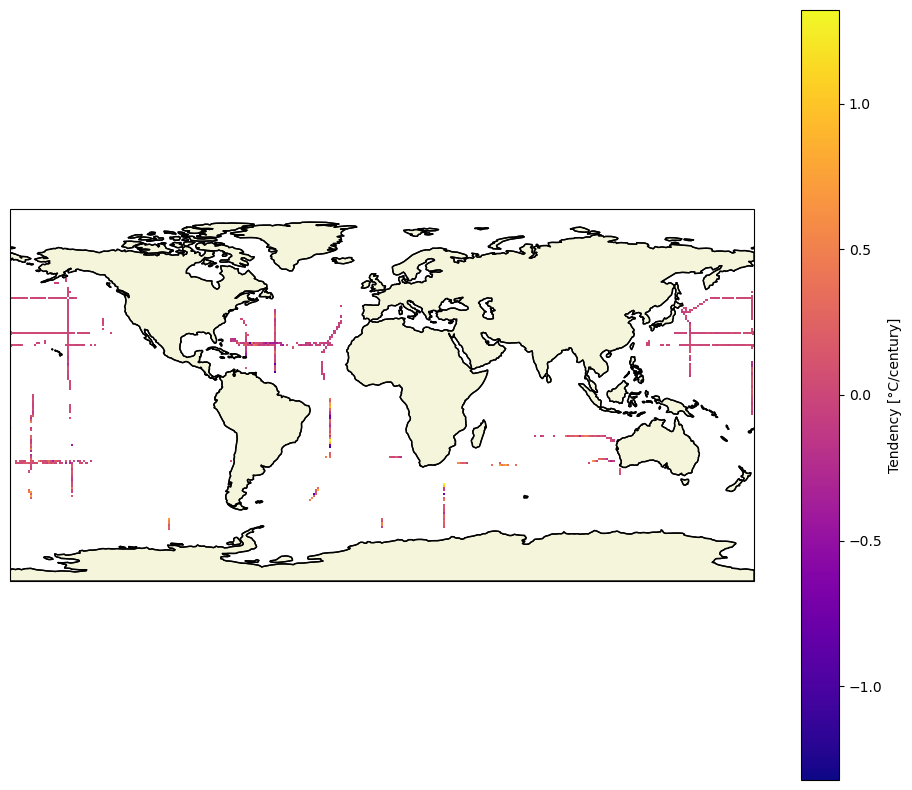

In [10]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature


fig = plt.figure(figsize=(12,10))

projection = ccrs.PlateCarree(central_longitude=0.0)
ax = plt.axes(projection=projection)
land = cartopy.feature.NaturalEarthFeature('physical',
                'land', edgecolor='k', scale = '110m' ,
                facecolor=cfeature.COLORS['land'])

ax.add_feature(land, facecolor='beige')
ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgrey')
ax.add_feature(cfeature.COASTLINE, zorder=2, edgecolor='black')
ds.tendency.plot(ax=ax, cmap='plasma', cbar_kwargs={'label': 'Tendency [°C/century]'})


In [11]:
# Find the indices of the maximum tendency
max_tendency_index = np.unravel_index(np.nanargmax(ds.tendency.values), ds.tendency.shape)

# Extract the latitude and longitude corresponding to the maximum tendency
max_latitude = ds.latitude[max_tendency_index[0]].values
max_longitude = ds.longitude[max_tendency_index[1]].values

print(f"Highest tendency: {ds.tendency.values[max_tendency_index]} °C/century")
print(f"Latitude: {max_latitude}, Longitude: {max_longitude}")

Highest tendency: 1.3218117643797558 °C/century
Latitude: -43.0, Longitude: 30.0


AttributeError: 'Dataset' object has no attribute 'sal_tendency'

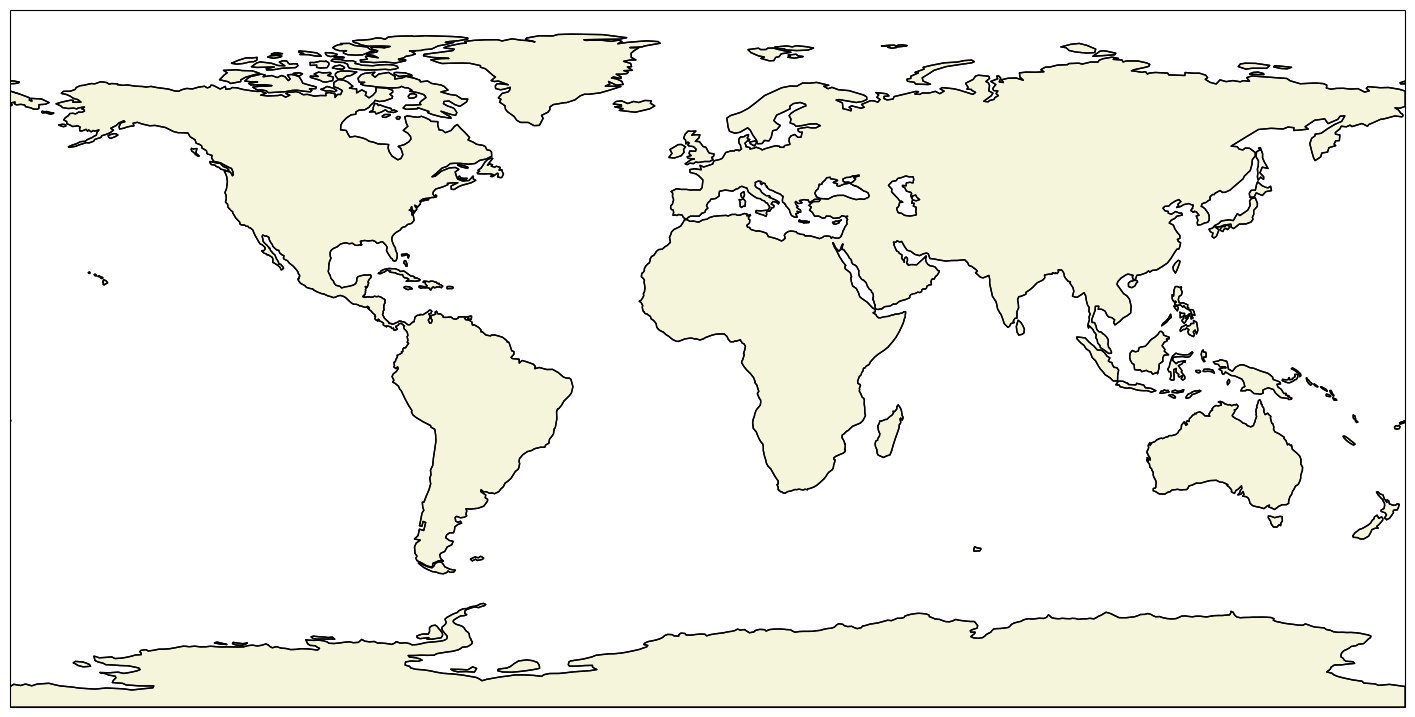

In [12]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature


fig = plt.figure(figsize=(18,14))

projection = ccrs.PlateCarree(central_longitude=0.0)
ax = plt.axes(projection=projection)
land = cartopy.feature.NaturalEarthFeature('physical',
                'land', edgecolor='k', scale = '110m' ,
                facecolor=cfeature.COLORS['land'])

ax.add_feature(land, facecolor='beige')
ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgrey')
ax.add_feature(cfeature.COASTLINE, zorder=2, edgecolor='black')

X, Y = np.meshgrid(ds.longitude.values,ds.latitude.values)
z=ds.sal_tendency.values

#ds.tendency.plot(ax=ax, cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'label': 'Tendency [°C/century]'})
hsc=ax.scatter(X,Y,c=z, cmap='plasma', s=10*ds.n.values, )
fig.colorbar(hsc)


Mean tendency: 0.0825907169792477 °C/century


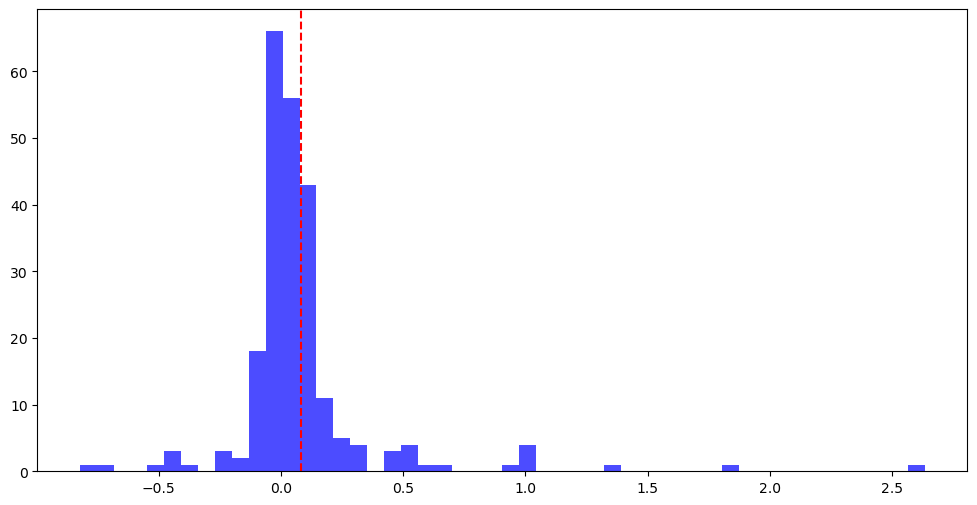

In [29]:
plt.figure(figsize=(12, 6))
plt.hist(ds.tendency.values.flatten(), bins=50, color='blue', alpha=0.7)
plt.axvline(x= np.nanmean(ds.tendency.values), color='red', linestyle='--', label='Mean tendency')

print(f"Mean tendency: {np.nanmean(ds.tendency.values)} °C/century")
#plt.ylim(0, 100)

In [27]:
def find_high_tendencies(ds, threshold= 10):
    
    """
    Encuentra todas las tendencias mayores al umbral especificado y devuelve sus coordenadas.

    Parameters:
        ds (xarray.Dataset): Dataset que contiene la variable 'tendency'.
        threshold (float): Umbral de tendencia en grados por siglo.

    Returns:
        list: Lista de tuplas con las coordenadas (latitud, longitud) de las tendencias mayores al umbral.
    """
    # Encuentra los índices donde la tendencia es mayor al umbral
    indices = np.where(ds.tendency.values > threshold)
    
    # Extrae las coordenadas correspondientes
    latitudes = ds.latitude.values[indices[0]]
    longitudes = ds.longitude.values[indices[1]]
    
    # Combina las coordenadas en una lista de tuplas
    coordinates = list(zip(latitudes, longitudes))
    
    return coordinates



# Uso de la función
high_tendency_coords = find_high_tendencies(ds, threshold=1)
print(f"Coordenadas con tendencias mayores a 10 °C/siglo: {high_tendency_coords}")


Coordenadas con tendencias mayores a 10 °C/siglo: [(-44.0, 30.0), (-43.0, 30.0), (-34.0, 57.0), (-34.0, 58.0), (16.0, -52.0)]


In [ ]:
# Daily data
ds = xr.open_dataset('./grid_1_sal.nc')

# Initialize an empty array to store the tendency values
tendency = np.full((len(ds.latitude), len(ds.longitude)), np.nan)

# Iterate over all latitude and longitude points
for i, lat in enumerate(ds.latitude.values):
    for j, lon in enumerate(ds.longitude.values):
        # Select the data for the current latitude and longitude
        t_means_1d = ds.t_means.sel(latitude=lat, longitude=lon, method="nearest")
        times_1d = ds.times.sel(latitude=lat, longitude=lon, method="nearest")
        
        # Check if there are enough valid data points to calculate the tendency
        ind = np.isfinite(t_means_1d)
        if ind.sum() > 1:  # Ensure there are at least 3 valid points
            # Check if the timespan is at least 2.5 years
            timespan = (times_1d.values[ind][-1] - times_1d.values[ind][0]).astype('timedelta64[D]').astype(int)
            if timespan >= 912.5:  # 2.5 years in days
                times_numeric = times_1d[ind].astype('datetime64[ns]').astype(np.int64)
                z = np.polyfit(times_numeric, t_means_1d[ind], 1)
                Dslope = z[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to °C per century
                tendency[i, j] = Dslope
# Add the tendency array as a new variable to the dataset
ds["tendency"] = (("latitude", "longitude"), tendency)


# Save the updated dataset to a new NetCDF file
ds.to_netcdf("grid_1_sal_45k_n1.nc")

In [49]:
# Daily data
ds = xr.open_dataset('./grid_1_sal.nc')

# Initialize empty arrays to store the tendency values for temperature and salinity
t_tendency = np.full((len(ds.latitude), len(ds.longitude)), np.nan)
sal_tendency = np.full((len(ds.latitude), len(ds.longitude)), np.nan)

# Iterate over all latitude and longitude points
for i, lat in enumerate(ds.latitude.values):
    for j, lon in enumerate(ds.longitude.values):
        # Select the data for the current latitude and longitude
        t_means_1d = ds.t_means.sel(latitude=lat, longitude=lon, method="nearest")
        sal_means_1d = ds.sal_means.sel(latitude=lat, longitude=lon, method="nearest")
        times_1d = ds.times.sel(latitude=lat, longitude=lon, method="nearest")
        
        # Check if there are enough valid data points to calculate the tendency for temperature
        ind_t = np.isfinite(t_means_1d)
        if ind_t.sum() > 1:  # Ensure there are at least 2 valid points
            # Check if the timespan is at least 2.5 years
            timespan_t = (times_1d.values[ind_t][-1] - times_1d.values[ind_t][0]).astype('timedelta64[D]').astype(int)
            if timespan_t >= 912.5:  # 2.5 years in days
                times_numeric_t = times_1d[ind_t].astype('datetime64[ns]').astype(np.int64)
                z_t = np.polyfit(times_numeric_t, t_means_1d[ind_t], 1)
                Dslope_t = z_t[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to °C per century
                t_tendency[i, j] = Dslope_t
        
        # Check if there are enough valid data points to calculate the tendency for salinity
        ind_s = np.isfinite(sal_means_1d)
        if ind_s.sum() > 1:  # Ensure there are at least 2 valid points
            # Check if the timespan is at least 2.5 years
            timespan_s = (times_1d.values[ind_s][-1] - times_1d.values[ind_s][0]).astype('timedelta64[D]').astype(int)
            if timespan_s >= 912.5:  # 2.5 years in days
                times_numeric_s = times_1d[ind_s].astype('datetime64[ns]').astype(np.int64)
                z_s = np.polyfit(times_numeric_s, sal_means_1d[ind_s], 1)
                Dslope_s = z_s[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to PSU per century
                sal_tendency[i, j] = Dslope_s

# Add the tendency arrays as new variables to the dataset
ds["t_tendency"] = (("latitude", "longitude"), t_tendency)
ds["sal_tendency"] = (("latitude", "longitude"), sal_tendency)

# Save the updated dataset to a new NetCDF file
ds.to_netcdf("grid_1_sal_45k_n1.nc")

# Daily data
ds = xr.open_dataset('./grid_1_sal.nc')

# Initialize empty arrays to store the tendency values for temperature and salinity
t_tendency = np.full((len(ds.latitude), len(ds.longitude)), np.nan)
sal_tendency = np.full((len(ds.latitude), len(ds.longitude)), np.nan)

# Iterate over all latitude and longitude points
for i, lat in enumerate(ds.latitude.values):
    for j, lon in enumerate(ds.longitude.values):
        # Select the data for the current latitude and longitude
        t_means_1d = ds.t_means.sel(latitude=lat, longitude=lon, method="nearest")
        sal_means_1d = ds.sal_means.sel(latitude=lat, longitude=lon, method="nearest")
        times_1d = ds.times.sel(latitude=lat, longitude=lon, method="nearest")
        
        # Check if there are enough valid data points to calculate the tendency for temperature
        ind_t = np.isfinite(t_means_1d)
        if ind_t.sum() > 2:  # Ensure there are at least 2 valid points
            # Check if the timespan is at least 2.5 years
            timespan_t = (times_1d.values[ind_t][-1] - times_1d.values[ind_t][0]).astype('timedelta64[D]').astype(int)
            if timespan_t >= 912.5:  # 2.5 years in days
                times_numeric_t = times_1d[ind_t].astype('datetime64[ns]').astype(np.int64)
                z_t = np.polyfit(times_numeric_t, t_means_1d[ind_t], 1)
                Dslope_t = z_t[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to °C per century
                t_tendency[i, j] = Dslope_t
        
        # Check if there are enough valid data points to calculate the tendency for salinity
        ind_s = np.isfinite(sal_means_1d)
        if ind_s.sum() > 2:  # Ensure there are at least 2 valid points
            # Check if the timespan is at least 2.5 years
            timespan_s = (times_1d.values[ind_s][-1] - times_1d.values[ind_s][0]).astype('timedelta64[D]').astype(int)
            if timespan_s >= 912.5:  # 2.5 years in days
                times_numeric_s = times_1d[ind_s].astype('datetime64[ns]').astype(np.int64)
                z_s = np.polyfit(times_numeric_s, sal_means_1d[ind_s], 1)
                Dslope_s = z_s[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to PSU per century
                sal_tendency[i, j] = Dslope_s

# Add the tendency arrays as new variables to the dataset
ds["t_tendency"] = (("latitude", "longitude"), t_tendency)
ds["sal_tendency"] = (("latitude", "longitude"), sal_tendency)

# Save the updated dataset to a new NetCDF file
ds.to_netcdf("grid_1_sal_45k_n2.nc")

# Daily data
ds = xr.open_dataset('./grid_1_9010_sal.nc')

# Initialize empty arrays to store the tendency values for temperature and salinity
t_tendency = np.full((len(ds.latitude), len(ds.longitude)), np.nan)
sal_tendency = np.full((len(ds.latitude), len(ds.longitude)), np.nan)

# Iterate over all latitude and longitude points
for i, lat in enumerate(ds.latitude.values):
    for j, lon in enumerate(ds.longitude.values):
        # Select the data for the current latitude and longitude
        t_means_1d = ds.t_means.sel(latitude=lat, longitude=lon, method="nearest")
        sal_means_1d = ds.sal_means.sel(latitude=lat, longitude=lon, method="nearest")
        times_1d = ds.times.sel(latitude=lat, longitude=lon, method="nearest")
        
        # Check if there are enough valid data points to calculate the tendency for temperature
        ind_t = np.isfinite(t_means_1d)
        if ind_t.sum() > 1:  # Ensure there are at least 2 valid points
            # Check if the timespan is at least 2.5 years
            timespan_t = (times_1d.values[ind_t][-1] - times_1d.values[ind_t][0]).astype('timedelta64[D]').astype(int)
            if timespan_t >= 912.5:  # 2.5 years in days
                times_numeric_t = times_1d[ind_t].astype('datetime64[ns]').astype(np.int64)
                z_t = np.polyfit(times_numeric_t, t_means_1d[ind_t], 1)
                Dslope_t = z_t[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to °C per century
                t_tendency[i, j] = Dslope_t
        
        # Check if there are enough valid data points to calculate the tendency for salinity
        ind_s = np.isfinite(sal_means_1d)
        if ind_s.sum() > 1:  # Ensure there are at least 2 valid points
            # Check if the timespan is at least 2.5 years
            timespan_s = (times_1d.values[ind_s][-1] - times_1d.values[ind_s][0]).astype('timedelta64[D]').astype(int)
            if timespan_s >= 912.5:  # 2.5 years in days
                times_numeric_s = times_1d[ind_s].astype('datetime64[ns]').astype(np.int64)
                z_s = np.polyfit(times_numeric_s, sal_means_1d[ind_s], 1)
                Dslope_s = z_s[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to PSU per century
                sal_tendency[i, j] = Dslope_s

# Add the tendency arrays as new variables to the dataset
ds["t_tendency"] = (("latitude", "longitude"), t_tendency)
ds["sal_tendency"] = (("latitude", "longitude"), sal_tendency)

# Save the updated dataset to a new NetCDF file
ds.to_netcdf("grid_1_9010_sal_45k_n1.nc")

# Daily data
ds = xr.open_dataset('./grid_1_9010_sal.nc')

# Initialize empty arrays to store the tendency values for temperature and salinity
t_tendency = np.full((len(ds.latitude), len(ds.longitude)), np.nan)
sal_tendency = np.full((len(ds.latitude), len(ds.longitude)), np.nan)

# Iterate over all latitude and longitude points
for i, lat in enumerate(ds.latitude.values):
    for j, lon in enumerate(ds.longitude.values):
        # Select the data for the current latitude and longitude
        t_means_1d = ds.t_means.sel(latitude=lat, longitude=lon, method="nearest")
        sal_means_1d = ds.sal_means.sel(latitude=lat, longitude=lon, method="nearest")
        times_1d = ds.times.sel(latitude=lat, longitude=lon, method="nearest")
        
        # Check if there are enough valid data points to calculate the tendency for temperature
        ind_t = np.isfinite(t_means_1d)
        if ind_t.sum() > 2:  # Ensure there are at least 2 valid points
            # Check if the timespan is at least 2.5 years
            timespan_t = (times_1d.values[ind_t][-1] - times_1d.values[ind_t][0]).astype('timedelta64[D]').astype(int)
            if timespan_t >= 912.5:  # 2.5 years in days
                times_numeric_t = times_1d[ind_t].astype('datetime64[ns]').astype(np.int64)
                z_t = np.polyfit(times_numeric_t, t_means_1d[ind_t], 1)
                Dslope_t = z_t[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to °C per century
                t_tendency[i, j] = Dslope_t
        
        # Check if there are enough valid data points to calculate the tendency for salinity
        ind_s = np.isfinite(sal_means_1d)
        if ind_s.sum() > 2:  # Ensure there are at least 2 valid points
            # Check if the timespan is at least 2.5 years
            timespan_s = (times_1d.values[ind_s][-1] - times_1d.values[ind_s][0]).astype('timedelta64[D]').astype(int)
            if timespan_s >= 912.5:  # 2.5 years in days
                times_numeric_s = times_1d[ind_s].astype('datetime64[ns]').astype(np.int64)
                z_s = np.polyfit(times_numeric_s, sal_means_1d[ind_s], 1)
                Dslope_s = z_s[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to PSU per century
                sal_tendency[i, j] = Dslope_s

# Add the tendency arrays as new variables to the dataset
ds["t_tendency"] = (("latitude", "longitude"), t_tendency)
ds["sal_tendency"] = (("latitude", "longitude"), sal_tendency)

# Save the updated dataset to a new NetCDF file
ds.to_netcdf("grid_1_9010_sal_45k_n2.nc")